## Assignment 10

Read in the height weight dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

## Problem 1

In [2]:
data = pd.read_csv("height_weight.csv")
x = data.height
y = data.weight

X = sm.add_constant(x)
model = sm.OLS(y, X)
results = model.fit()

In [3]:
## Problem 3

In [4]:
df = pd.read_csv("couples_heights.csv")

X_wh = sm.add_constant(df["husband_height"])  # adds intercept
y_wh = df["wife_height"]

model_wh = sm.OLS(y_wh, X_wh).fit()

b0_wh = model_wh.params["const"]
b1_wh = model_wh.params["husband_height"]

X_hw = sm.add_constant(df["wife_height"])
y_hw = df["husband_height"]

model_hw = sm.OLS(y_hw, X_hw).fit()

b0_hw = model_hw.params["const"]
b1_hw = model_hw.params["wife_height"]

x = np.linspace(df["husband_height"].min(), df["husband_height"].max(), 200)
y = np.linspace(df["wife_height"].min(), df["wife_height"].max(), 200)






## Problem 5

Read in the temperature sugars database

In [5]:
df = pd.read_csv("temperature_sugars.csv")
df.columns = ["temperature", "sugar"]

# Fit linear regression model
X = sm.add_constant(df["temperature"])
model = sm.OLS(df["sugar"], X).fit()

print(model.summary())



                            OLS Regression Results                            
Dep. Variable:                  sugar   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.444
Method:                 Least Squares   F-statistic:                     8.996
Date:                Mon, 13 Apr 2026   Prob (F-statistic):             0.0150
Time:                        15:52:34   Log-Likelihood:                -9.4677
No. Observations:                  11   AIC:                             22.94
Df Residuals:                       9   BIC:                             23.73
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           6.4136      0.925      6.936      

Use `s2 = model.mse_resid`

0.40019191919191954


## Problem 7

Regression line:
course_grade = 32.5059 + 0.4711(placement_grade)

Predicted placement test cutoff for a course grade of 60:
58.3658


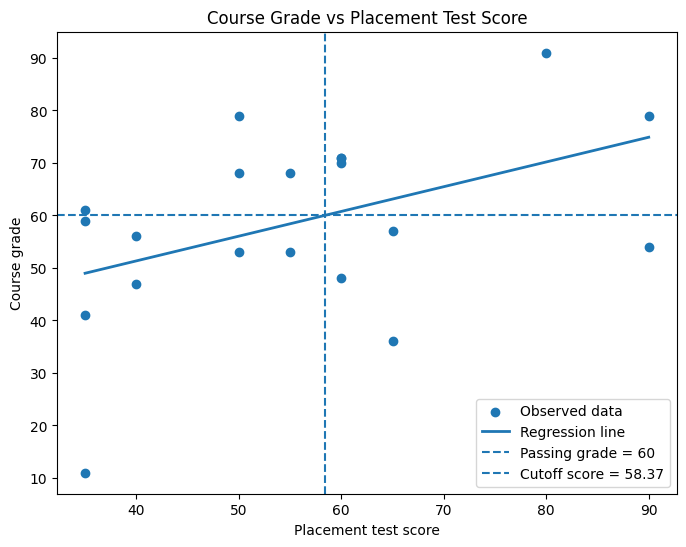


Regression summary:
                            OLS Regression Results                            
Dep. Variable:           course_grade   R-squared:                       0.206
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     4.661
Date:                Mon, 13 Apr 2026   Prob (F-statistic):             0.0446
Time:                        15:52:34   Log-Likelihood:                -82.994
No. Observations:                  20   AIC:                             170.0
Df Residuals:                      18   BIC:                             172.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              32

In [7]:
df = pd.read_csv("placement_grade.csv")
df.columns = ["placement_grade", "course_grade"]

x = df["placement_grade"]
y = df["course_grade"]

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()



In [ ]:
## Problem 8

In [8]:
beta0_hat = model.params["const"]
se_beta0 = model.bse["const"]
df_resid = model.df_resid

beta0_0 = 10


1.7807254620976447
0.9540792874716462


## Problem 9

In [9]:
df1 = pd.DataFrame({
    "strength": [17.5,16.9,15.8,18.6,
                 16.4,19.2,17.7,15.4,
                 20.3,15.7,17.8,18.9,
                 14.6,16.7,20.8,18.9,
                 17.5,19.2,16.5,20.5,
                 18.3,16.2,17.5,20.1],
    "machine": (["1"]*4 + ["2"]*4 + ["3"]*4 +
                ["4"]*4 + ["5"]*4 + ["6"]*4)
})

model1 = ols("strength ~ C(machine)", data=df1).fit()

anova1 = sm.stats.anova_lm(model1, typ=1)
print(anova1)

              df     sum_sq   mean_sq         F    PR(>F)
C(machine)   5.0   5.338333  1.067667  0.306801  0.902421
Residual    18.0  62.640000  3.480000       NaN       NaN


## Problem 10

In [10]:
# Create dataframe
df2 = pd.DataFrame({
    "relief": [5.2,4.7,8.1,6.2,3.0,
               9.1,7.1,8.2,6.0,9.1,
               3.2,5.8,2.2,3.1,7.2,
               2.4,3.4,4.1,1.0,4.0,
               7.1,6.6,9.3,4.2,7.6],
    "brand": (["A"]*5 + ["B"]*5 + ["C"]*5 +
              ["D"]*5 + ["E"]*5)
})

model2 = ols("relief ~ C(brand)", data=df2).fit()

anova2 = sm.stats.anova_lm(model2, typ=1)
print(anova2)

            df   sum_sq  mean_sq         F    PR(>F)
C(brand)   4.0  78.4216  19.6054  6.586508  0.001497
Residual  20.0  59.5320   2.9766       NaN       NaN
